In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import base64

from functools import reduce
from urllib.parse import urlencode, urlunparse,quote, quote_plus


In [76]:
def read_cred():
    f = open("../../../cred.txt", "r")
    cred = f.read()
    f.close()
    return cred
urlBase = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?'
credentials = read_cred()

In [77]:
def get_OI(url,start,end,interval='PT1M',tag='xx',auth='xx',hS='00',hF='23'):
	url_all =url+'data-reference='+tag+'&aggregation=TIME'+'&aggregation-function=MEAN'+"&from="+start+"T"+hS+"%3A00%3A00.000Z&to="+end+"T"+hF+"%3A59%3A59.000Z&aggregation-period="+interval
	#print(url_all,auth)
	d_data = pd.read_json(url_all,storage_options={ 'Authorization': 'basic '+ auth})
	# print(d_data['values'][0])
	arr = np.asarray(np.asarray(d_data['values'])[0])
	return d_data['values'][0]

In [78]:
def get_data(tags,start, end):
    liste = list(range(0))
    for tag in tags:
        urlTag = quote(tag, safe=':/?#[]@!$&\'()*+,;=')
        data = get_OI(urlBase,start,end,'PT20M',urlTag,credentials,'00','23')
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        df = df.rename(columns={'value':tag})
        liste.append(df)
    return liste

In [79]:
def merge_data(liste):
    df = reduce(lambda left,right : pd.merge(left, right,left_index=True,right_index=True,how='outer'),liste)
    return df

In [ ]:
def detecter_campagnes(df, seuil_jours=30):
    """
    Détecte les campagnes et ajoute plusieurs colonnes d'information
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    df = df.sort_index()
    
    # Calculer les différences
    diff_jours = df.index.to_series().diff().dt.days
    
    # Détecter les nouvelles campagnes
    nouvelle_campagne = (diff_jours > seuil_jours) | (diff_jours.isna())
    
    # Numéro de campagne
    df['campagne'] = nouvelle_campagne.cumsum()
    
    # Date de début de chaque campagne
    df['debut_campagne'] = df.groupby('campagne').apply(lambda x: x.index.min()).loc[df['campagne']].values
    
    # Nombre de jours depuis le début de la campagne
    df['jour_campagne'] = (df.index - df['debut_campagne']).days
    
    return df


In [147]:
def detecter_campagnes_v2(df, seuil_jours=3):
    df = df.sort_index().copy()

    # Calcul de l'écart de temps entre deux points consécutifs
    deltas = df.index.to_series().diff()

    # Nouvelle campagne si delta > seuil_jours
    nouvelle_campagne = deltas > pd.Timedelta(days=seuil_jours)

    # Numérotation : on cumule les True
    df["campagne"] = nouvelle_campagne.cumsum() + 1

    # Ajout colonne mois-année au format mm-aa
    df["mois_annee"] = df.index.strftime("%m-%y")

    return df


In [154]:
brute.describe()

,CTY_A1000M_Poids container,CTY_A1000M_Teneur arr. Vit. A (UV),CTY_A1000M_Titre VA AC,CTY_FHA1000M_Teneur_VA
count,13817.000000,3.588730e+05,3.291270e+05,1.968070e+05
mean,1062.344597,1.033946e+06,1.018705e+06,1.026288e+06
std,90.454573,5.540244e+04,1.103427e+05,1.329546e+04
min,5.000000,0.000000e+00,0.000000e+00,5.701004e+05
25%,1022.000000,1.019000e+06,1.000000e+06,1.017777e+06
50%,1070.000000,1.036000e+06,1.025000e+06,1.025840e+06
75%,1109.000000,1.048000e+06,1.045000e+06,1.033801e+06
max,2585.428571,1.027070e+07,9.794000e+06,1.075963e+06


In [155]:
tags = ['CTY_A1000M_Poids container','CTY_A1000M_Teneur arr. Vit. A (UV)','CTY_A1000M_Titre VA AC','CTY_FHA1000M_Teneur_VA'] #'CTY_A1000M_Poids container']
start = '2010-01-01'
end = '2025-11-29'
df_list = get_data(tags,start,end)
data = merge_data(df_list)
brute = data.copy()
result = data.copy()
brute.describe()

,CTY_A1000M_Poids container,CTY_A1000M_Teneur arr. Vit. A (UV),CTY_A1000M_Titre VA AC,CTY_FHA1000M_Teneur_VA
count,13817.000000,3.588730e+05,3.291270e+05,1.968070e+05
mean,1062.344597,1.033946e+06,1.018705e+06,1.026288e+06
std,90.454573,5.540244e+04,1.103427e+05,1.329546e+04
min,5.000000,0.000000e+00,0.000000e+00,5.701004e+05
25%,1022.000000,1.019000e+06,1.000000e+06,1.017777e+06
50%,1070.000000,1.036000e+06,1.025000e+06,1.025840e+06
75%,1109.000000,1.048000e+06,1.045000e+06,1.033801e+06
max,2585.428571,1.027070e+07,9.794000e+06,1.075963e+06


In [81]:
def filtering(df):
    df = df.dropna()
    df = df[(df['CTY_A1000M_Poids container']>700) & (df['CTY_A1000M_Poids container']<1300)]
    df = df[(df['CTY_A1000M_Teneur arr. Vit. A (UV)']>800_000) & (df['CTY_A1000M_Teneur arr. Vit. A (UV)']<1_300_000)]
    df = df[(df['CTY_A1000M_Titre VA AC']>700_000) & (df['CTY_A1000M_Titre VA AC']<1_300_000)]
    return df

In [82]:
def plot_data(liste, tags):
    for tag in tags:
        plt.figure(figsize=(18,6))
        
        # Calcul de la moyenne et de la médiane
        moyenne = liste[tag].mean()
        mediane = liste[tag].median()
        
        # Subplot 1 : Scatter plot
        plt.subplot(121)
        plt.scatter(liste.index, liste[tag], label=tag, c='b', alpha=0.3)
        
        # Lignes horizontales pour moyenne et médiane
        plt.axhline(y=moyenne, color='red', linestyle='--', linewidth=1, label=f'Moyenne: {moyenne:.2f}')
        plt.axhline(y=mediane, color='violet', linestyle='--', linewidth=1, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()
        
        # Subplot 2 : Histogramme
        plt.subplot(122)
        sns.histplot(liste[tag], label=tag, kde=True, common_norm=True)
        
        # Lignes verticales pour moyenne et médiane dans l'histogramme
        plt.axvline(x=moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {moyenne:.2f}')
        plt.axvline(x=mediane, color='violet', linestyle='--', linewidth=2, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()

In [83]:
def ajoute_cumul(df):
    """
    Ajoute deux colonnes au dataframe :
    - cumul_UV : (colonne 0 * colonne 1) / 1_000_000
    - cumul_Labo : (colonne 0 * colonne 2) / 1_000_000
    
    Parameters:
    df : DataFrame pandas
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    df['cumul_UV'] = (df.iloc[:, 0] * df.iloc[:, 1]) / 1_000_000
    df['cumul_Labo'] = (df.iloc[:, 0] * df.iloc[:, 2]) / 1_000_000
    
    return df

In [84]:
def ajouter_moyennes_glissantes(df, window=10):
    """
    Ajoute deux colonnes de moyennes pondérées glissantes :
    - cumul_UV : moyenne pondérée de la colonne 2 par la colonne 1 sur les 10 dernières valeurs
    - cumul_Labo : moyenne pondérée de la colonne 3 par la colonne 1 sur les 10 dernières valeurs
    
    Parameters:
    df : DataFrame pandas
    window : int, nombre de valeurs pour la fenêtre glissante (défaut: 10)
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    # Extraction des colonnes
    poids = df.iloc[:, 0]
    valeurs_uv = df.iloc[:, 1]
    valeurs_labo = df.iloc[:, 2]
    
    # Calcul de la moyenne pondérée glissante pour UV
    numerateur_uv = (poids * valeurs_uv).rolling(window=window).sum()
    denominateur = poids.rolling(window=window).sum()
    df['cumul_UV'] = numerateur_uv / denominateur
    
    # Calcul de la moyenne pondérée glissante pour Labo
    numerateur_labo = (poids * valeurs_labo).rolling(window=window).sum()
    df['cumul_Labo'] = numerateur_labo / denominateur
    
    return df

# Utilisation
# brute = ajouter_moyennes_glissantes(brute, window=10)

In [156]:
def resume_par_campagne(df):
    # On suppose que df contient déjà la colonne "campagne"
    # et que les colonnes sont : Poids, UV, labo, teneur

    # UV pondéré = somme(Poids * UV) / somme(Poids)
    df["UV_pondere"] = df["CTY_A1000M_Poids container"] * df["CTY_A1000M_Teneur arr. Vit. A (UV)"]

    grouped = df.groupby(["campagne","mois-annee"]).agg(
        nb_lots=("CTY_A1000M_Poids container", "count"),
        poids_total=("CTY_A1000M_Poids container", "sum"),
        uv_pondere=("UV_pondere", lambda x: x.sum() / df.loc[x.index, "CTY_A1000M_Poids container"].sum())
    )

    return grouped.reset_index()


In [157]:
def plot_campagnes(resume):
    plt.figure(figsize=(12, 6))

    # Barres : poids total
    ax = sns.barplot(
        data=resume,
        x="campagne",
        y="nb_lots",
        color="skyblue",
        label="# lots"
    )

    # Deuxième axe pour UV pondéré
    ax2 = ax.twinx()
    sns.lineplot(
        data=resume,
        x="campagne",
        y="uv_pondere",
        marker="o",
        color="red",
        linewidth=2,
        ax=ax2,
        label="UV pondéré"
    )

    # Titres et légendes
    ax.set_xlabel("Campagne")
    ax.set_ylabel("nb_lots")
    ax2.set_ylabel("UV pondéré")

    # Gestion des légendes combinées
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left")

    plt.title("Poids total et UV pondéré par campagne")
    plt.tight_layout()
    plt.show()

       CTY_A1000M_Poids container  CTY_A1000M_Teneur arr. Vit. A (UV)  \
count                 8653.000000                        8.653000e+03   
mean                  1074.147477                        1.031356e+06   
std                     71.351292                        2.642791e+04   
min                    703.000000                        8.690000e+05   
25%                   1029.000000                        1.017000e+06   
50%                   1077.000000                        1.033000e+06   
75%                   1122.000000                        1.048000e+06   
max                   1295.000000                        1.135000e+06   

       CTY_A1000M_Titre VA AC  CTY_FHA1000M_Teneur_VA      cumul_UV  \
count            8.653000e+03            8.653000e+03  8.634000e+03   
mean             1.032077e+06            1.026389e+06  1.031295e+06   
std              2.634117e+04            1.346248e+04  2.059120e+04   
min              7.562306e+05            9.709870e+05  9.3

TypeError: Could not convert string '07-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1807-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-1808-

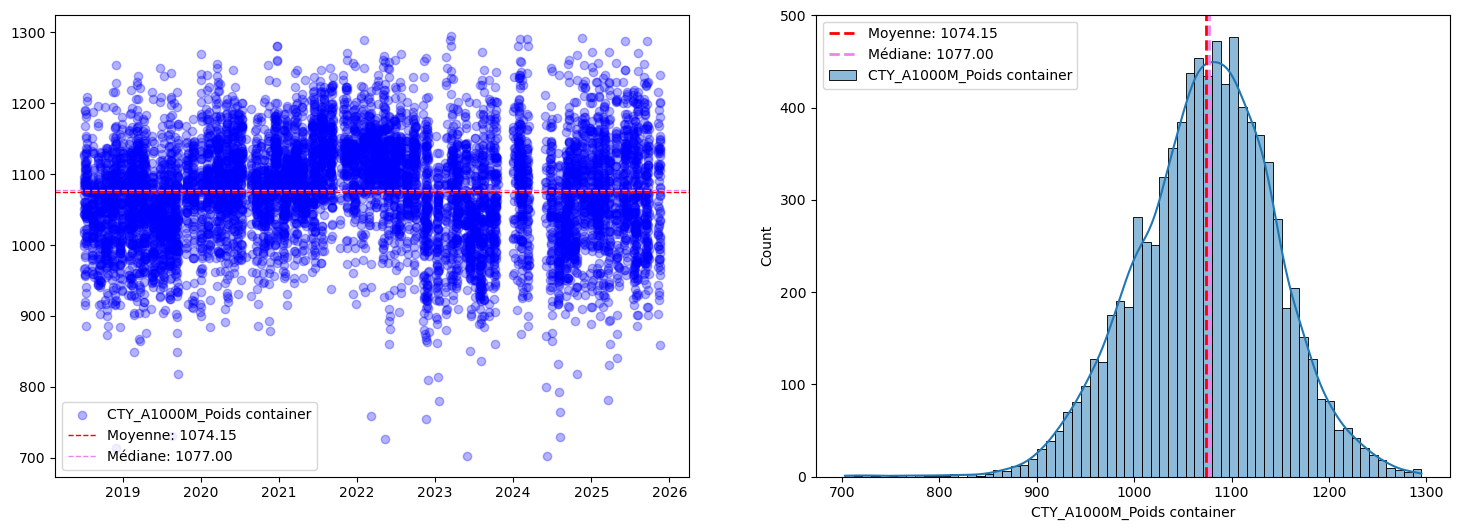

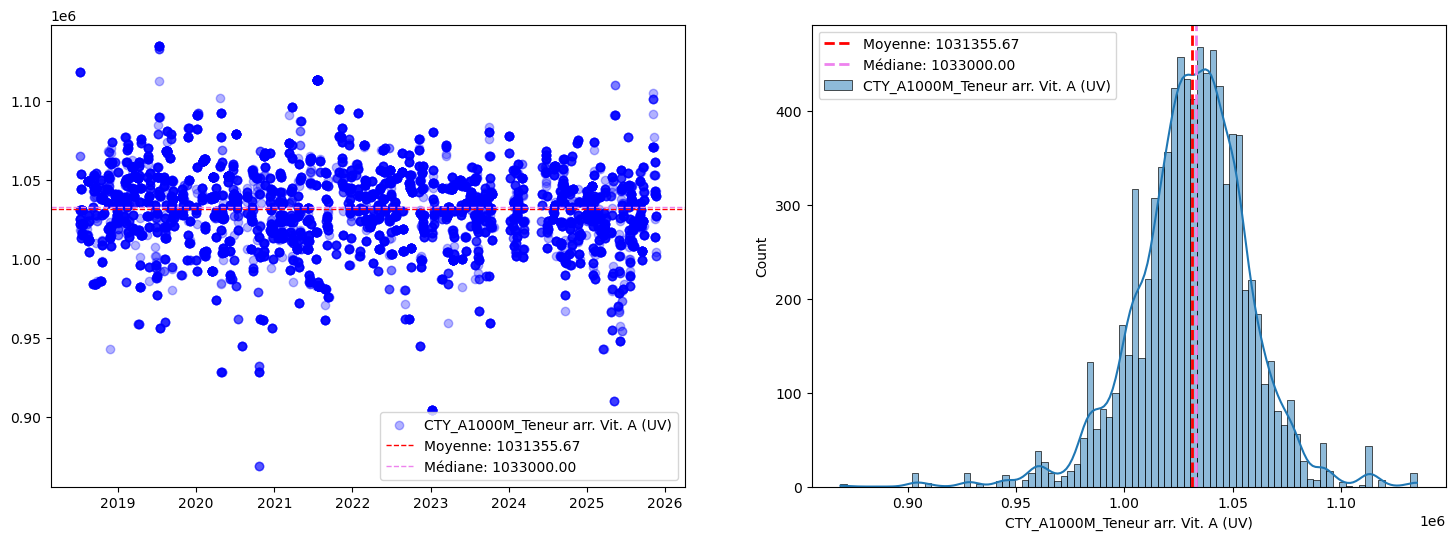

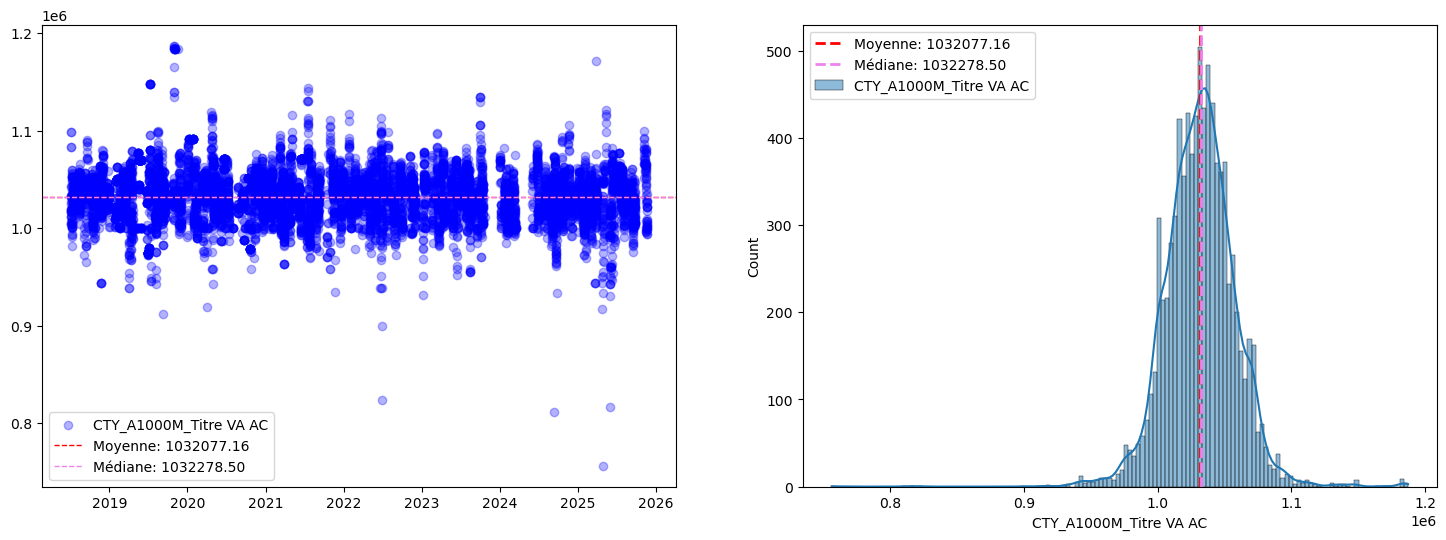

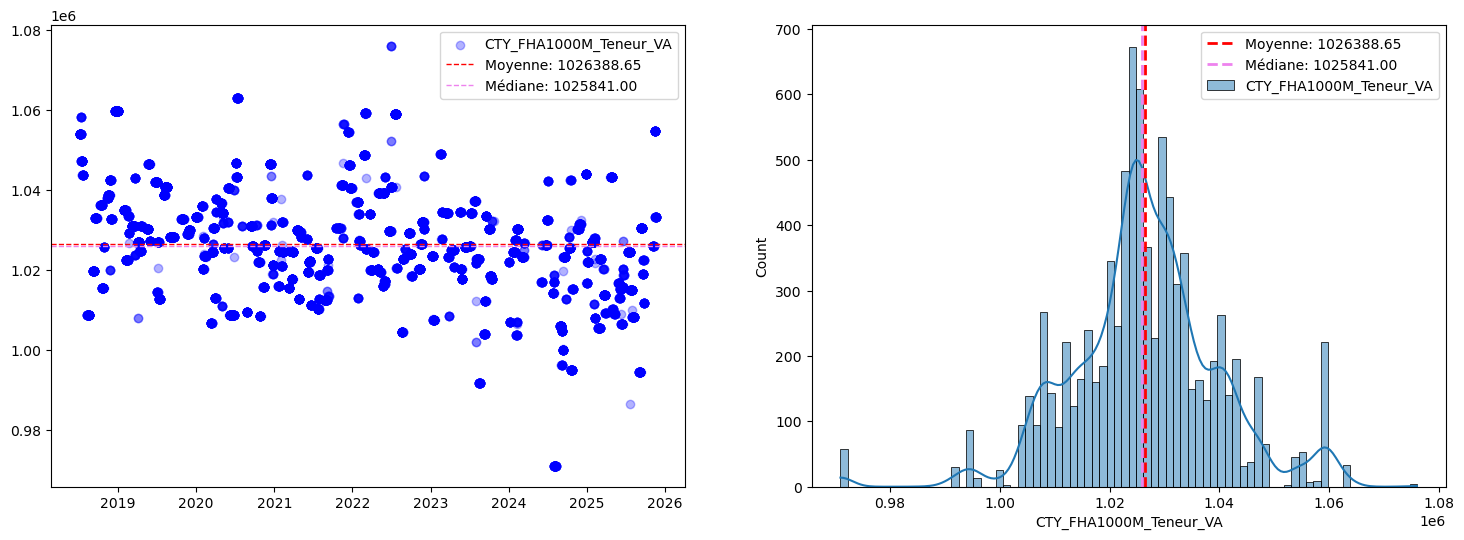

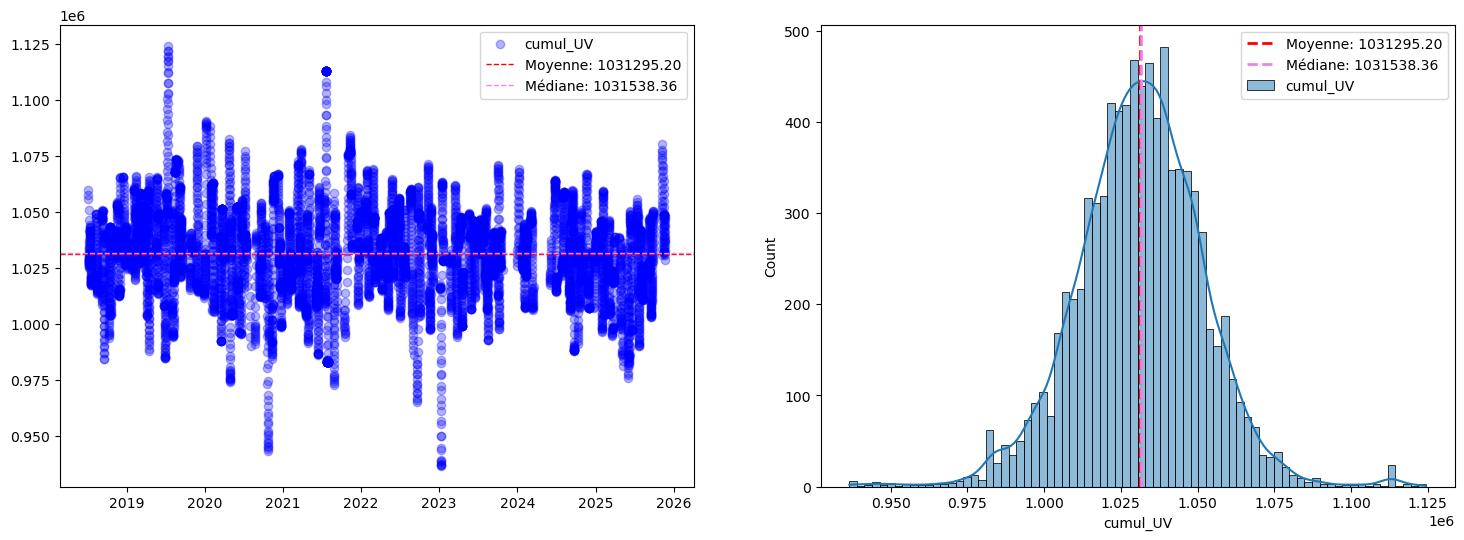

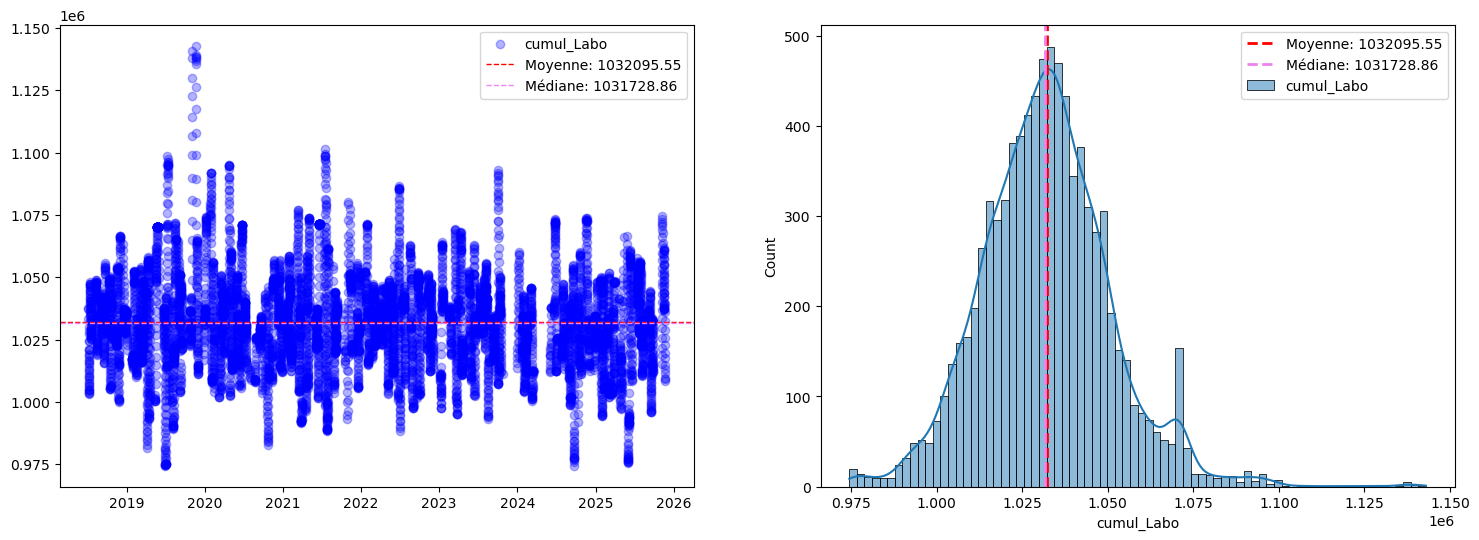

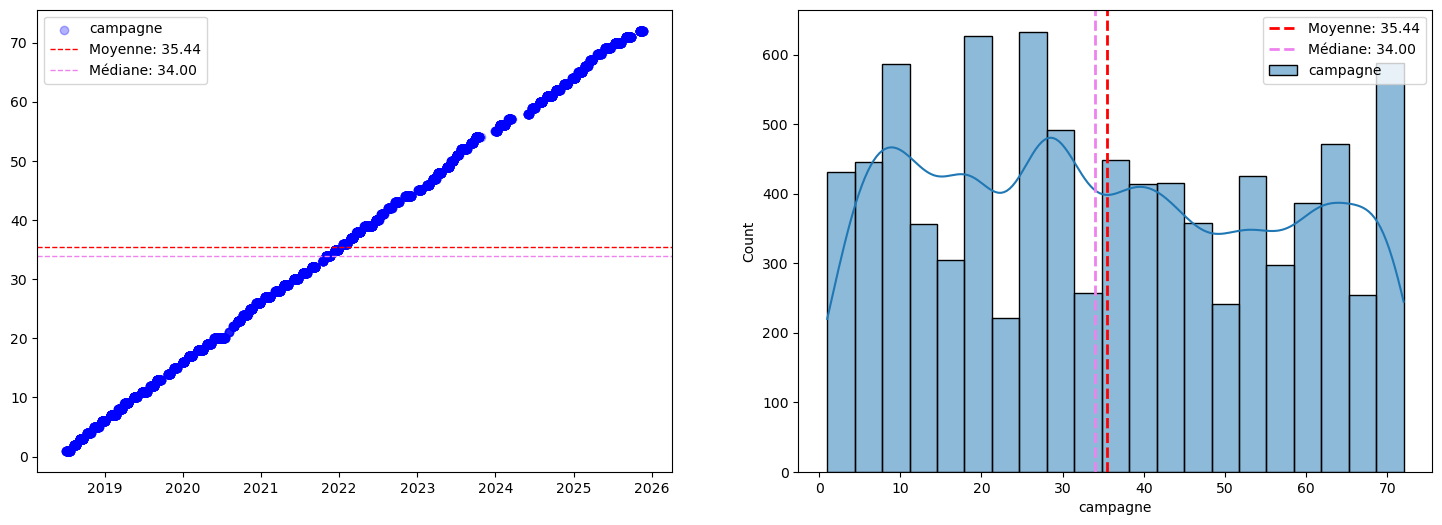

<Figure size 1800x600 with 0 Axes>

In [158]:
result = brute.copy()
result = filtering(result)
result = ajouter_moyennes_glissantes(result,20)
result = detecter_campagnes_v2(result, seuil_jours=10)
print(result.describe())
tags_ = result.columns.tolist()
plot_data(result, tags_)

In [ ]:

plot_data(result, tags_)


In [161]:
campagnes.describe()

,campagne,nb_lots,poids_total,uv_pondere
count,72.00000,72.000000,72.000000,7.200000e+01
mean,36.50000,120.180556,129091.640509,1.030395e+06
std,20.92845,50.349015,54833.734882,1.345944e+04
min,1.00000,6.000000,6397.000000,9.450000e+05
25%,18.75000,89.250000,95299.750000,1.025952e+06
50%,36.50000,113.000000,123262.250000,1.031361e+06
75%,54.25000,154.250000,165127.375000,1.036490e+06
max,72.00000,280.000000,306904.000000,1.062386e+06


In [160]:
campagnes = resume_par_campagne(result)
campagnes

KeyError: 'mois-annee'

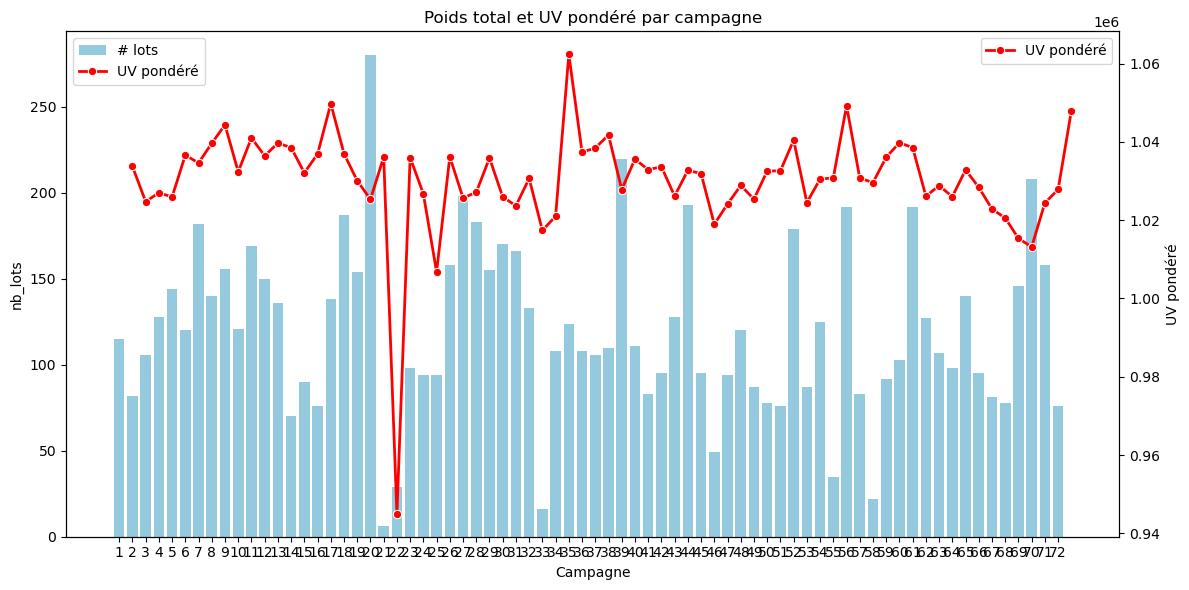

In [143]:
plot_campagnes(campagnes)